In [1]:
!nvidia-smi

Fri Jan 23 03:32:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:03:00.0 Off |                    0 |
| N/A   32C    P0             72W /  400W |       1MiB /  40960MiB |      7%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import sys
sys.path.append('./src')

This notebook may take quite a bit longer than the quickstart notebook. We set $n_{max}=8$ for the shapelets because this is the minimal number needed to capture the spiral arms features on the source galaxy, resulting in slower modeling. This is in part due to the higher memory pressure associated with a large number of shapelets components.

In [3]:
import tensorflow_probability.substrates.jax as tfp
import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
import matplotlib as mpl
from matplotlib import pyplot as plt
from corner import corner

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic, shapelets
from gigalens.jax.profiles.mass import epl, shear, sis

tfd = tfp.distributions

Load the data. The ground truth parameters are in `truth`. Various hyperparameters, including the noise scale and exposure time are fixed.

The PSF is generated from `TinyTim` for HST F140W band, and has been supersampled to the pixel scale of 0.065.

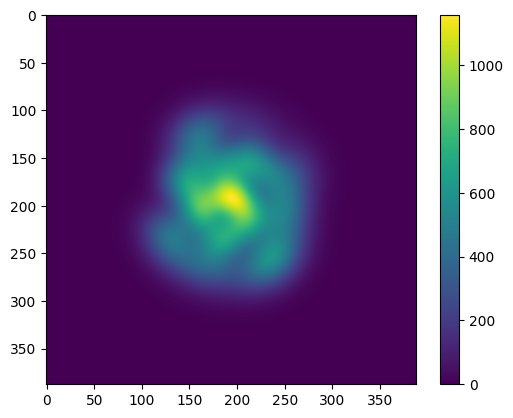

In [4]:
import gigalens
root = gigalens.__path__[0]
img = plt.imread(f'{root}/assets/M101.jpeg')
img = img[:,131:-131]
img = jnp.sqrt(img[...,1].astype(np.float32))
img -= np.median(img[:20,:20])
img *= 100
from skimage.transform import downscale_local_mean
img = downscale_local_mean(img, (5,5))
img = np.pad(img, [(100, 100), (100, 100)], mode='constant')
grid = jnp.linspace(-1,1,len(img)).astype(np.float32)
xx,yy = jnp.meshgrid(grid,grid)
xx, yy = xx[jnp.newaxis,...,jnp.newaxis], yy[jnp.newaxis,...,jnp.newaxis]
n_max = 8
shp = shapelets.Shapelets(n_max=n_max, interpolate=False, use_lstsq=True)
components = jnp.squeeze(shp.light(xx, yy, beta=0.13, center_x=0, center_y=0))
X = components.reshape((shp.depth, -1))
Y = img.flatten()
sol, resid, _, _ = jnp.linalg.lstsq(X.T, Y)
plt.imshow((sol@X).reshape(img.shape))
plt.colorbar()

In [5]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.0), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(0, 0.025),
                center_y=tfd.Normal(0, 0.025),
            )
        ),
    ]
)

amp_prior = {key: tfd.Normal(0,500/float(jnp.sqrt(i+1))) for i, key in enumerate(shapelets.Shapelets(n_max)._amp_names)}
source_light_params = dict(
    beta=tfd.LogNormal(jnp.log(0.1), 0.15),
    center_x=tfd.Normal(0, 0.01),
    center_y=tfd.Normal(0, 0.01)
)

source_light_prior = tfd.JointDistributionSequential([tfd.JointDistributionNamed(source_light_params)])

prior = tfd.JointDistributionSequential(
    [lens_prior, source_light_prior]
)

In [6]:
seed = 0
key = jax.random.PRNGKey(seed)
truth = prior.sample(1,seed=key)
truth[1][0] = {**truth[1][0], 
               **{f'amp{str(i).zfill(2)}': jnp.array([sol[i]]) for i in range(shp.depth)}, 
               'beta': jnp.array([0.08], dtype=jnp.float32),
              }

In [7]:
import gigalens
root = gigalens.__path__[0] + '/assets'
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=60, supersample=1)
phys_model = PhysicalModel([epl.EPL(), shear.Shear()], [], [shapelets.Shapelets(n_max=n_max, use_lstsq=False, interpolate=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
observed_img = lens_sim.simulate(truth)
err_map = np.sqrt(0.1**2 + np.clip(observed_img, 0, np.inf)/200)
np.random.seed(1)
observed_img += np.random.normal(scale=err_map)

phys_model = PhysicalModel([epl.EPL(), shear.Shear()], [], [shapelets.Shapelets(n_max=n_max, use_lstsq=True, interpolate=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
prob_model = BackwardProbModel(prior, observed_img, background_rms=0.1, exp_time=200)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

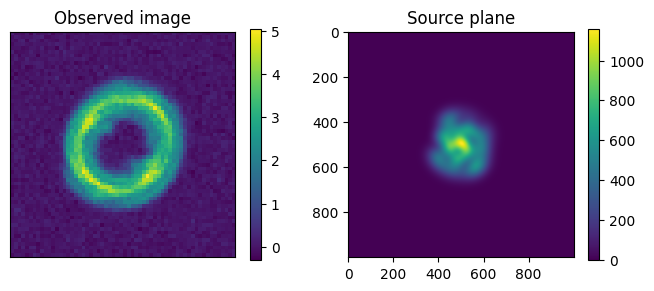

In [8]:
plt.figure(figsize=(8,3))
plt.subplot(121)
plt.imshow(observed_img)
plt.title('Observed image')
plt.colorbar() 
plt.xticks([])
plt.yticks([])
plt.subplot(122)
shp = shapelets.Shapelets(n_max=n_max, interpolate=False, use_lstsq=False)
grid = np.linspace(-1,1,1000).astype(np.float32)
a, b = np.meshgrid(grid,grid)
ret = shp.light(a[np.newaxis,...,np.newaxis], b[np.newaxis,...,np.newaxis], **truth[1][0])
plt.imshow(np.squeeze(ret))
plt.title('Source plane')
plt.grid(False)
plt.colorbar()

Begin fitting:

In [9]:
fitter = ModellingSequence(phys_model, prob_model, sim_config)

See $\S2.3$: Maximum a Posteriori Estimate

In [10]:
n_map = 100
optimizer = optax.adabelief(1e-2, b1=0.95, b2=0.99)
MAP = fitter.MAP(optimizer=optimizer, n_samples=n_map, num_steps=150, seed=0)

Chi-squared: 0.956: 100%|██████████| 150/150 [00:13<00:00, 11.26it/s]


Final Chi-squared: 0.95623


In [11]:
# Simulator to evaluate the log likelihood of 100 candidate solutions
lens_sim_100 = LensSimulator(phys_model, sim_config, bs=n_map)
lps = prob_model.log_prob(lens_sim_100, MAP[0])[0]
best = MAP[0][jnp.nanargmax(lps)][jnp.newaxis,:]

In [12]:
print((MAP[0][1]))

[-8.7755797e-03  1.4189686e-02  1.7061798e-02  1.3408694e-01
 -3.7665984e-01 -2.5693855e-01 -2.5276434e+00  2.0163786e-03
 -2.8870269e-03]


See $\S2.4$: Variational Inference

In [13]:
opt = optax.adabelief(1e-2, b1=0.95, b2=0.99)
q_z, losses = fitter.SVI(optimizer=optimizer, start=best, n_vi=500, num_steps=350)

-ELBO: -2871.817: 100%|██████████| 350/350 [01:06<00:00,  5.25it/s]


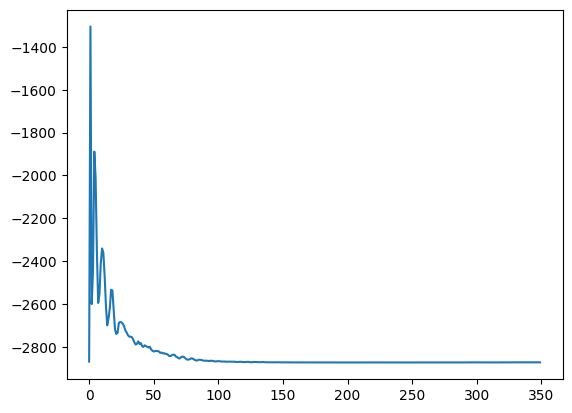

In [14]:
plt.plot(losses)

See $\S2.5$: Hamiltonian Monte Carlo

In [15]:
samples = fitter.HMC(q_z, n_hmc=50, init_eps=0.3, init_l=3, max_leapfrog_steps=300,
                                   num_burnin_steps=250, num_results=750,pbar_interval=25)

HMC Progress: 100%|██████████| 1000/1000 [00:36<00:00, 27.06it/s]

Sampling took 37.0s


In [16]:
Rhat= tfp.mcmc.potential_scale_reduction(samples, independent_chain_ndims=2)
ESS = tfp.mcmc.effective_sample_size(samples, cross_chain_dims=[1,2])
for i, rh in enumerate(Rhat):
    print(i,rh,ESS[i])

0 1.0018046 14386.928
1 1.0023427 16438.172
2 1.0013729 17455.834
3 1.0016717 17810.918
4 1.0010576 19107.584
5 1.0010817 21628.223
6 1.0013876 20272.748
7 1.0012106 13959.651
8 1.0022253 15152.6045


Create a corner plot with sampling results:

In [17]:
num_params = len(Rhat)
smp = samples.reshape((-1, num_params))
smp_physical = prob_model.bij.forward(list(smp.T))

dict_indices = [(0, 0), (1, 0)]
label_prefixes = ["", "src_"]

labels = np.hstack([[label_prefixes[i] + key for key in smp_physical[i][j].keys()] for (i,j) in dict_indices])
plt_samples = np.vstack(
    [jnp.array(list(smp_physical[i][j].values())) for (i,j) in dict_indices]
).T

markers = np.hstack([np.squeeze(list(truth[0][0].values())),[truth[1][0][label].item() for label in ['center_y','center_x','beta']]])

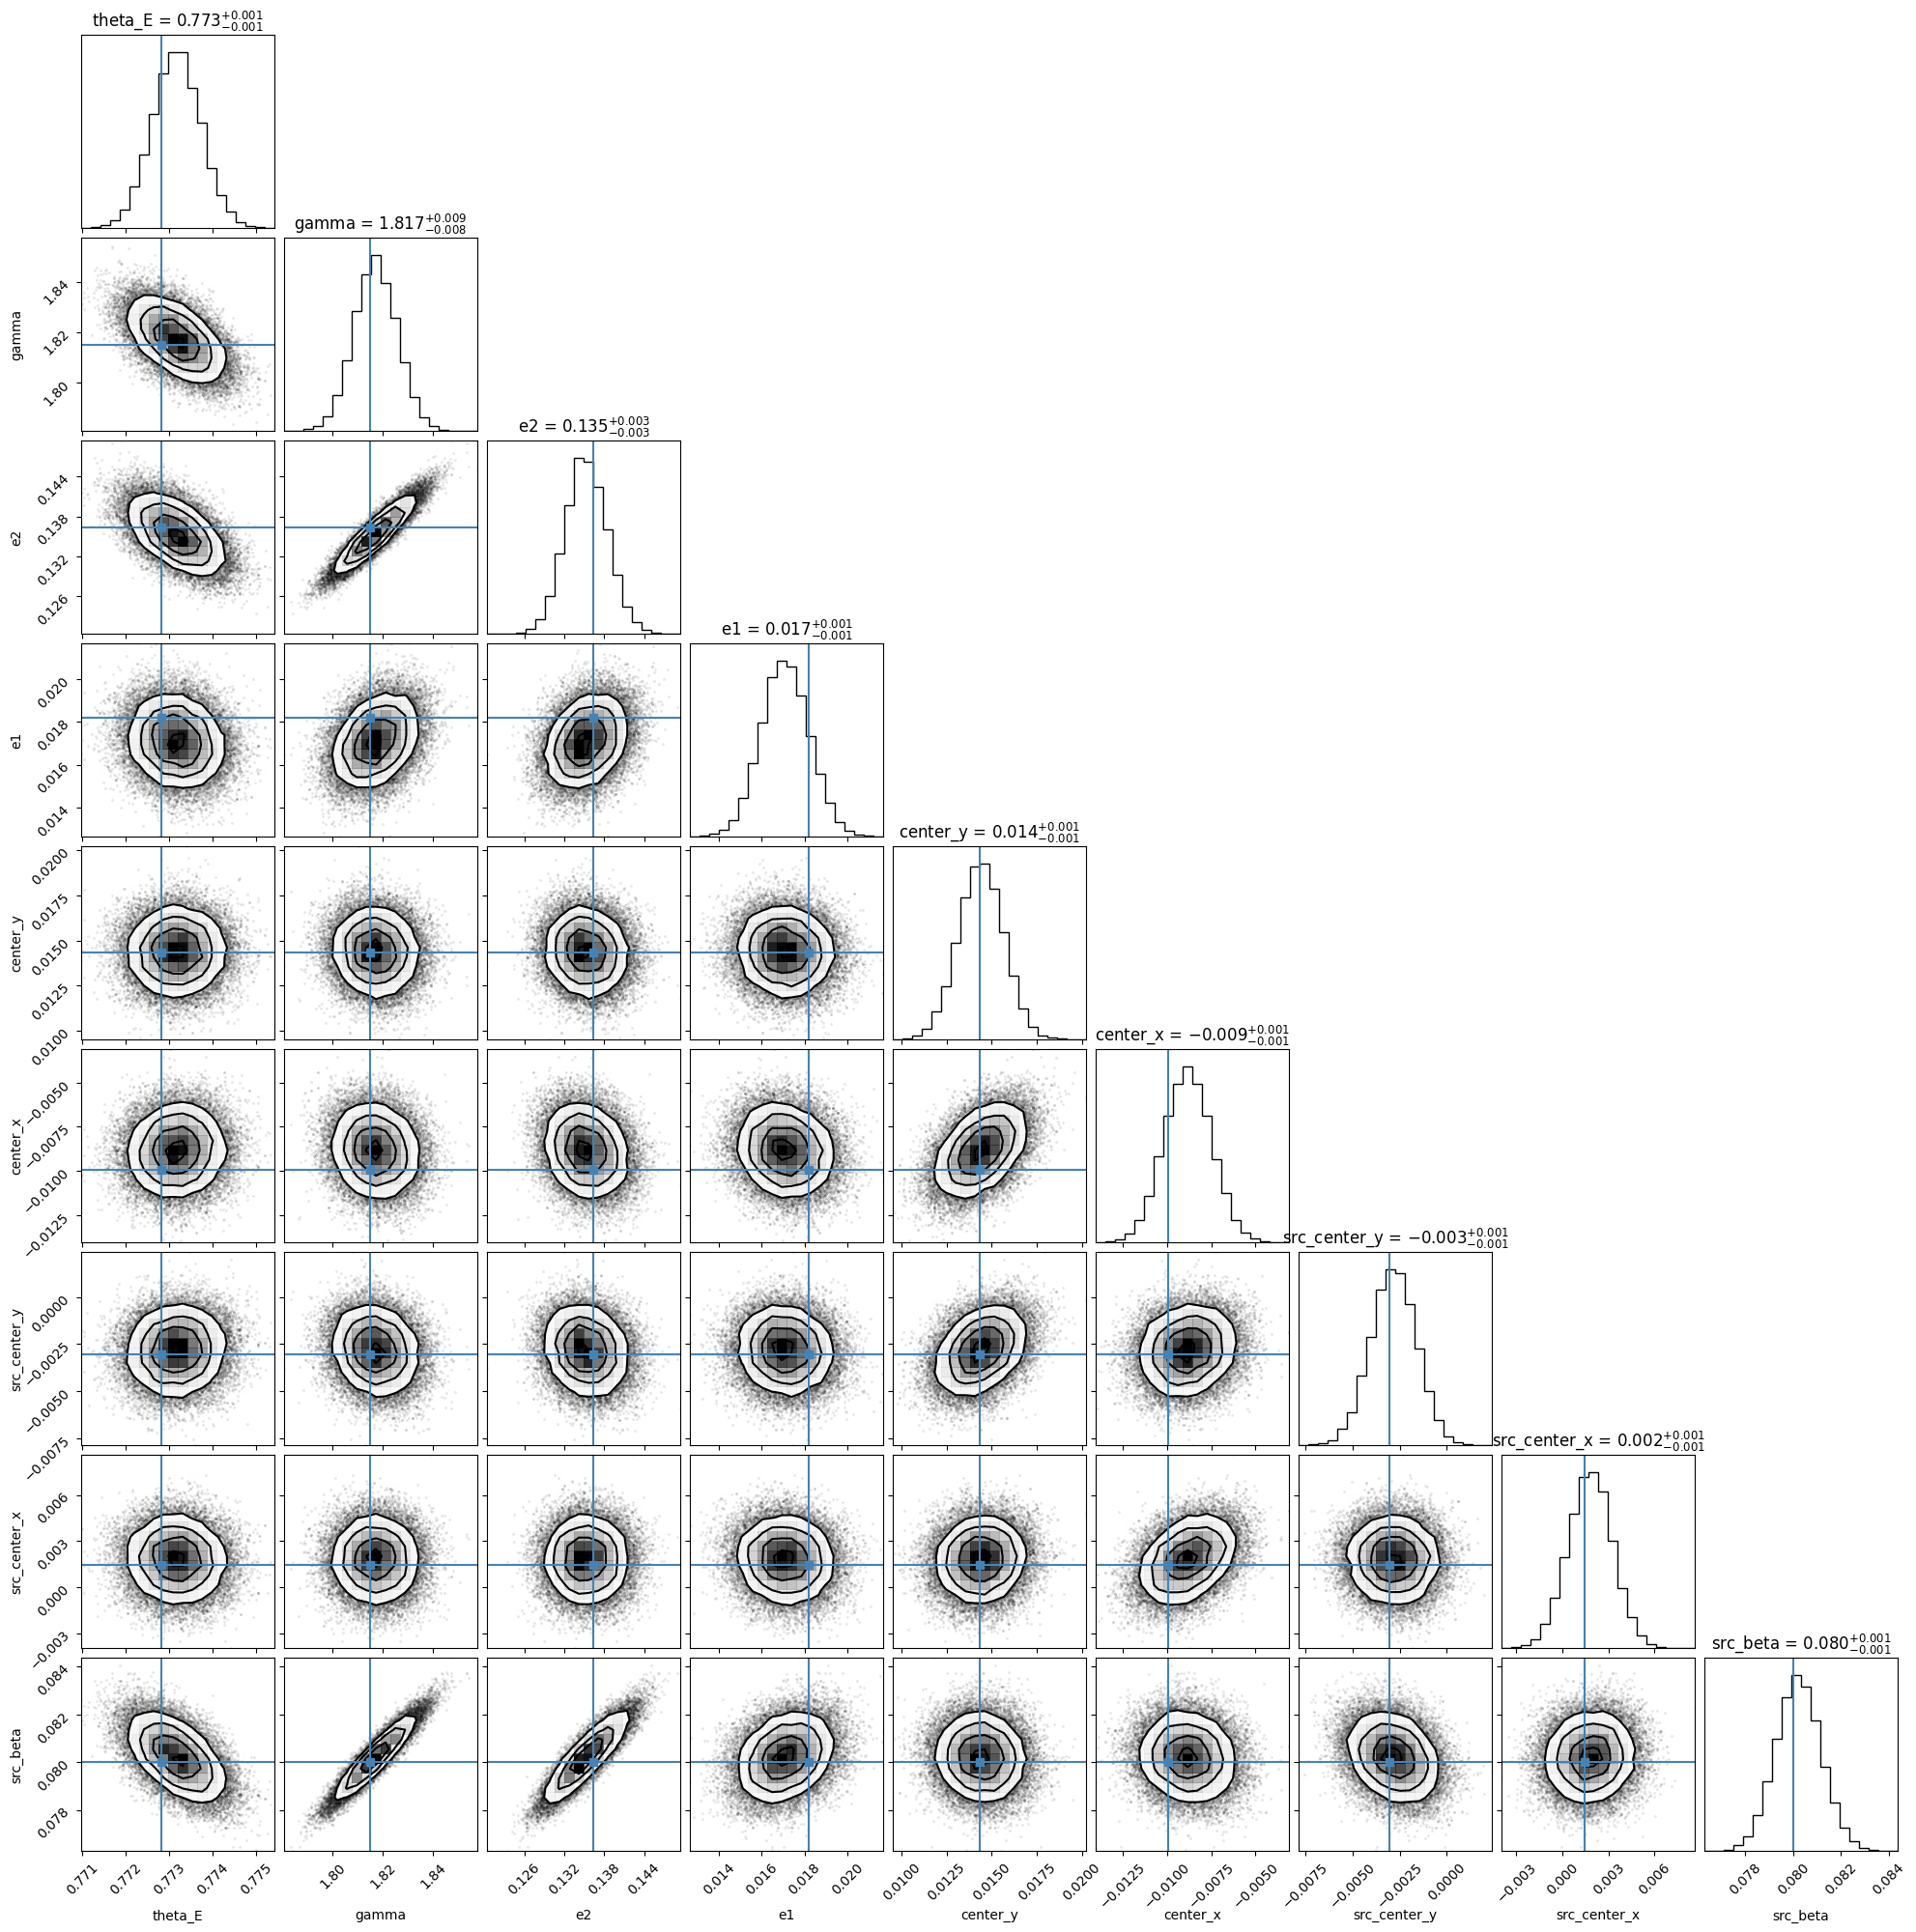

In [18]:
fig = corner(plt_samples, show_titles=True, title_fmt='.3f', labels=labels, truths=markers)

Visualize the result:

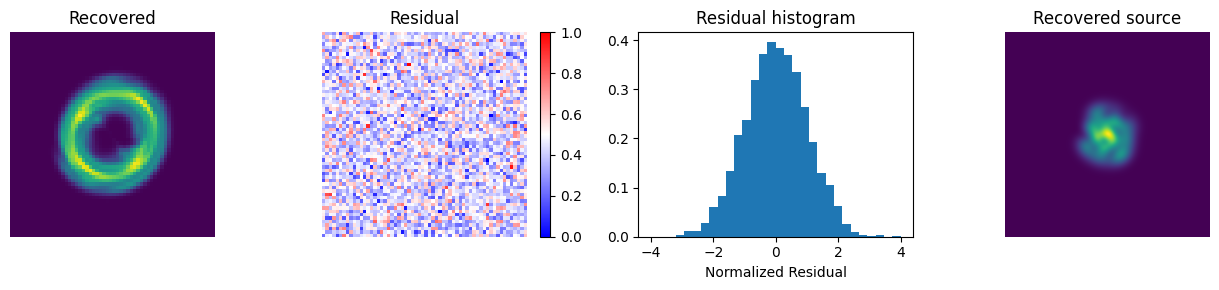

In [19]:
mean_estimate= [[{key:jnp.mean(value) for key,value in par.items()} for par in cat]for cat in smp_physical]

residual = (observed_img-lens_sim.lstsq_simulate(mean_estimate, observed_img, err_map)[0])/err_map 

coeffs = lens_sim.lstsq_simulate(mean_estimate, observed_img, err_map)[1]
shp = shapelets.Shapelets(n_max=n_max, interpolate=False, use_lstsq=False)
grid = jnp.linspace(-1,1,1000).astype(jnp.float32)
a, b = jnp.meshgrid(grid,grid)
ret = shp.light(a[np.newaxis,...,np.newaxis], b[np.newaxis,...,np.newaxis], **mean_estimate[1][0], 
               **{shp._amp_names[i]: jnp.array([coeffs[i]]) for i in range(shp.depth)})

fig, ax = plt.subplots(1,4,figsize=(13,3))

ax[0].set_title('Recovered')
ax[0].imshow(lens_sim.lstsq_simulate(mean_estimate, observed_img, err_map)[0])
ax[0].set_axis_off()

ax[1].set_title('Residual')
ax[1].imshow(residual, cmap='bwr', interpolation='none')
fig.colorbar(mpl.cm.ScalarMappable(cmap='bwr'),ax=ax[1])
ax[1].set_axis_off()

ax[2].set_title('Residual histogram')
ax[2].hist(residual.flatten(), range=(-4,4), density=True, bins=30)
ax[2].set_xlabel('Normalized Residual')

ax[3].set_title('Recovered source')
ax[3].imshow(jnp.squeeze(ret))
ax[3].set_axis_off()
fig.tight_layout()